In [5]:
%%capture
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), "..", "src"))
from data_loading    import load_data
from elo_ratings     import compute_elo
from player_profiles import compute_player_profiles
from h2h             import compute_h2h
from features        import build_dataset, ALL_FEATURES
from features import ROLL_COLS, SURF_COLS, EWM_COLS
from training        import train_all_models, evaluate, baseline_rank, \
                            plot_results, plot_feature_importance, leakage_diagnostic
from predict         import predict_matchup
raw      = load_data()
elo_df   = compute_elo(raw)
profiles = compute_player_profiles(raw)
h2h      = compute_h2h(raw)
df       = build_dataset(raw, profiles, h2h, elo_df)

trained, X_train, X_test, y_train, y_test = train_all_models(df)

baseline_auc, baseline_prob = baseline_rank(X_test, y_test)
results = [evaluate(name, model, X_test, y_test) for name, model in trained.items()]

ModuleNotFoundError: No module named 'panda'

tourney_level values: ['A', 'D', 'F', 'G', 'M', 'O']
round values:         ['BR', 'F', 'QF', 'R128', 'R16', 'R32', 'R64', 'RR', 'SF']

Finals found: 55
Processed : 54
Skipped — no profile  : 0
Skipped — no elo      : 0
Skipped — low history : 1

  GRAND SLAM FINALS — ranked by model uncertainty
      date      tournament surface         winner                 loser                          score  P(winner wins)  closeness
2020-09-28   Roland Garros    Clay   Rafael Nadal        Novak Djokovic                    6-0 6-2 7-5          0.5000     0.0000
2014-05-26   Roland Garros    Clay   Rafael Nadal        Novak Djokovic                3-6 7-5 6-2 6-4          0.5055     0.0055
2014-08-25         US Open    Hard    Marin Cilic         Kei Nishikori                    6-3 6-3 6-3          0.5055     0.0055
2011-06-20       Wimbledon   Grass Novak Djokovic          Rafael Nadal                6-4 6-1 1-6 6-3          0.5511     0.0511
2019-07-01       Wimbledon   Grass Novak Djokovic     

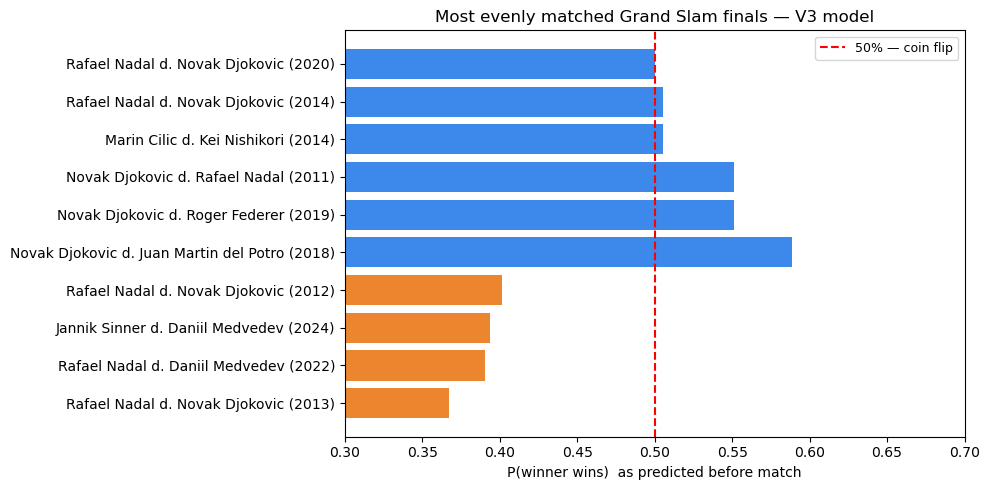

💾 Saved: closest_finals_v3.png


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from predict import predict_match


def find_closest_final_v3(raw, profiles, h2h, elo_df, trained,
                            slam_only=True, top_n=10):
    """
    Scans Grand Slam finals (or all finals) and finds the ones
    the model considered most evenly matched (closest to 50%).
    Uses the full V3 feature set including Elo.
    """
    model = trained.get("XGBoost") or list(trained.values())[0]

    # ── Filter finals ─────────────────────────────────────────────────────
    print("tourney_level values:", sorted(raw["tourney_level"].dropna().unique()))
    print("round values:        ", sorted(raw["round"].dropna().unique()))

    level_vals = ["G"]
    round_vals = ["F"]

    finals = raw[
        raw["tourney_level"].isin(level_vals) &
        raw["round"].isin(round_vals)
    ].copy() if slam_only else raw[raw["round"].isin(round_vals)].copy()

    print(f"\nFinals found: {len(finals)}")
    if finals.empty:
        print("⛔ No finals found — adjust level_vals / round_vals")
        return None

    all_roll_keys = ROLL_COLS + SURF_COLS + EWM_COLS

    # ── Static rank lookup (most recent before each match) ────────────────
    def _get_static(pid, field, date):
        sub = raw[
            ((raw["winner_id"]==pid) | (raw["loser_id"]==pid)) &
            (raw["tourney_date"] <= date)
        ].sort_values("tourney_date")
        for _, r in sub.iloc[::-1].iterrows():
            for pref in ["winner","loser"]:
                if r.get(f"{pref}_id")==pid and pd.notna(r.get(f"{pref}_{field}")):
                    return float(r[f"{pref}_{field}"])
        return np.nan

    # ── Main loop ──────────────────────────────────────────────────────────
    records = []
    skipped_no_profile  = 0
    skipped_no_elo      = 0
    skipped_low_history = 0

    for _, match in finals.iterrows():
        mid  = f"{match['tourney_id']}_{match['match_num']}"
        wid  = match["winner_id"]
        lid  = match["loser_id"]
        date = match["tourney_date"]

        # Profiles
        try:
            wp = profiles.loc[(wid, mid)]
            lp = profiles.loc[(lid, mid)]
        except KeyError:
            skipped_no_profile += 1
            continue

        if wp["n_past"] < 5 or lp["n_past"] < 5:
            skipped_low_history += 1
            continue

        # Elo
        try:
            elo_row     = elo_df.loc[mid]
            w_elo       = float(elo_row["winner_elo"])
            l_elo       = float(elo_row["loser_elo"])
            w_elo_s     = float(elo_row["winner_elo_surf"])
            l_elo_s     = float(elo_row["loser_elo_surf"])
        except KeyError:
            skipped_no_elo += 1
            continue

        # H2H (winner = player A perspective)
        h2h_a, h2h_b, h2h_n = 0.5, 0.5, 0.0
        pair = raw[
            ((raw["winner_id"]==wid)&(raw["loser_id"]==lid)) |
            ((raw["winner_id"]==lid)&(raw["loser_id"]==wid))
        ].sort_values("tourney_date")
        past = pair[pair["tourney_date"] < date]
        if not past.empty:
            ref     = past.iloc[-1]
            ref_mid = f"{ref['tourney_id']}_{ref['match_num']}"
            try:
                h2h_a = float(h2h.loc[(wid, lid, ref_mid)]["h2h_win_rate"])
                h2h_n = float(h2h.loc[(wid, lid, ref_mid)]["h2h_n"])
            except KeyError:
                pass
            try:
                h2h_b = float(h2h.loc[(lid, wid, ref_mid)]["h2h_win_rate"])
            except KeyError:
                pass

        # Build features from winner's perspective (y=1)
        features = {
            "rank_diff":         _get_static(wid,"rank",date)        - _get_static(lid,"rank",date),
            "rank_pts_diff":     _get_static(wid,"rank_points",date) - _get_static(lid,"rank_points",date),
            "age_diff":          _get_static(wid,"age",date)         - _get_static(lid,"age",date),
            "ht_diff":           _get_static(wid,"ht",date)          - _get_static(lid,"ht",date),
            "best_of":           5,
            "surface":           match.get("surface"),
            "tourney_level":     "G",
            "round":             "F",
            "h2h_win_rate_diff": h2h_a - h2h_b,
            "h2h_n":             h2h_n,
            "elo_diff":          w_elo   - l_elo,
            "elo_surface_diff":  w_elo_s - l_elo_s,
            **{f"{k}_diff": wp[k] - lp[k] for k in all_roll_keys
               if not (np.isnan(float(wp[k])) or np.isnan(float(lp[k])))},
        }

        prob = predict_match(model, features)["P(A wins)"]

        records.append({
            "date":            date.date(),
            "tournament":      match.get("tourney_name"),
            "surface":         match.get("surface"),
            "winner":          match.get("winner_name"),
            "loser":           match.get("loser_name"),
            "score":           match.get("score"),
            "P(winner wins)":  round(prob, 4),
            "closeness":       abs(prob - 0.5),
        })

    print(f"Processed : {len(records):,}")
    print(f"Skipped — no profile  : {skipped_no_profile}")
    print(f"Skipped — no elo      : {skipped_no_elo}")
    print(f"Skipped — low history : {skipped_low_history}")

    if not records:
        print("⛔ No matches processed")
        return None

    df_finals = (pd.DataFrame(records)
                   .sort_values("closeness")
                   .reset_index(drop=True))

    print("\n" + "="*75)
    print(f"  {'GRAND SLAM' if slam_only else 'ALL'} FINALS — ranked by model uncertainty")
    print("="*75)
    print(df_finals.head(top_n).to_string(index=False))

    top = df_finals.iloc[0]
    print(f"\nMost balanced final ever:")
    print(f"  {top['winner']} def. {top['loser']}")
    print(f"  {top['tournament']} {top['date']}  —  {top['score']}")
    print(f"  Model gave the winner only {top['P(winner wins)']:.1%} chance beforehand")

    # ── Plot top 10 ───────────────────────────────────────────────────────
    top10 = df_finals.head(top_n).copy()
    top10["label"] = top10["winner"] + " d. " + top10["loser"] + \
                     " (" + top10["date"].astype(str).str[:4] + ")"

    fig, ax = plt.subplots(figsize=(10, 5))
    colors = ["#1a73e8" if p >= 0.5 else "#e8710a"
              for p in top10["P(winner wins)"]]
    ax.barh(top10["label"], top10["P(winner wins)"],
            color=colors, alpha=0.85)
    ax.axvline(0.5, color="red", lw=1.5, linestyle="--", label="50% — coin flip")
    ax.set_xlabel("P(winner wins)  as predicted before match")
    ax.set_title(f"Most evenly matched {'Grand Slam' if slam_only else ''} finals — V3 model")
    ax.set_xlim(0.3, 0.7)
    ax.invert_yaxis()
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig("closest_finals_v3.png", dpi=150)
    plt.show()
    print("💾 Saved: closest_finals_v3.png")

    return df_finals


closest = find_closest_final_v3(raw, profiles, h2h, elo_df, trained)

In [ ]:
def find_biggest_upsets(raw, profiles, h2h, elo_df, trained,
                         min_matches=5, top_n=15, level=None):
    """
    Finds matches where the actual winner was given the lowest
    probability by the model — genuine upsets.
    """
    model = trained.get("XGBoost") or list(trained.values())[0]
    all_roll_keys = ROLL_COLS + SURF_COLS + EWM_COLS

    def _get_static(pid, field, date):
        sub = raw[
            ((raw["winner_id"]==pid)|(raw["loser_id"]==pid)) &
            (raw["tourney_date"] <= date)
        ].sort_values("tourney_date")
        for _, r in sub.iloc[::-1].iterrows():
            for pref in ["winner","loser"]:
                if r.get(f"{pref}_id")==pid and pd.notna(r.get(f"{pref}_{field}")):
                    return float(r[f"{pref}_{field}"])
        return np.nan

    subset = raw.copy()
    if level:
        subset = subset[subset["tourney_level"] == level]

    records = []
    for _, match in subset.iterrows():
        mid  = f"{match['tourney_id']}_{match['match_num']}"
        wid  = match["winner_id"]
        lid  = match["loser_id"]
        date = match["tourney_date"]

        try:
            wp = profiles.loc[(wid, mid)]
            lp = profiles.loc[(lid, mid)]
        except KeyError:
            continue
        if wp["n_past"] < min_matches or lp["n_past"] < min_matches:
            continue
        try:
            elo_row = elo_df.loc[mid]
        except KeyError:
            continue

        h2h_a, h2h_b, h2h_n = 0.5, 0.5, 0.0
        pair = raw[
            ((raw["winner_id"]==wid)&(raw["loser_id"]==lid)) |
            ((raw["winner_id"]==lid)&(raw["loser_id"]==wid))
        ].sort_values("tourney_date")
        past = pair[pair["tourney_date"] < date]
        if not past.empty:
            ref_mid = f"{past.iloc[-1]['tourney_id']}_{past.iloc[-1]['match_num']}"
            try:
                h2h_a = float(h2h.loc[(wid,lid,ref_mid)]["h2h_win_rate"])
                h2h_n = float(h2h.loc[(wid,lid,ref_mid)]["h2h_n"])
            except KeyError: pass
            try:
                h2h_b = float(h2h.loc[(lid,wid,ref_mid)]["h2h_win_rate"])
            except KeyError: pass

        features = {
            "rank_diff":         _get_static(wid,"rank",date)        - _get_static(lid,"rank",date),
            "rank_pts_diff":     _get_static(wid,"rank_points",date) - _get_static(lid,"rank_points",date),
            "age_diff":          _get_static(wid,"age",date)         - _get_static(lid,"age",date),
            "ht_diff":           _get_static(wid,"ht",date)          - _get_static(lid,"ht",date),
            "best_of":           match.get("best_of"),
            "surface":           match.get("surface"),
            "tourney_level":     match.get("tourney_level"),
            "round":             match.get("round"),
            "h2h_win_rate_diff": h2h_a - h2h_b,
            "h2h_n":             h2h_n,
            "elo_diff":          float(elo_row["winner_elo"])      - float(elo_row["loser_elo"]),
            "elo_surface_diff":  float(elo_row["winner_elo_surf"]) - float(elo_row["loser_elo_surf"]),
            **{f"{k}_diff": wp[k] - lp[k] for k in all_roll_keys
               if not (np.isnan(float(wp[k])) or np.isnan(float(lp[k])))},
        }

        prob = predict_match(model, features)["P(A wins)"]
        records.append({
            "date":       date.date(),
            "tournament": match.get("tourney_name"),
            "surface":    match.get("surface"),
            "round":      match.get("round"),
            "winner":     match.get("winner_name"),
            "loser":      match.get("loser_name"),
            "score":      match.get("score"),
            "P(winner)":  round(prob, 4),
        })

    df_upsets = (pd.DataFrame(records)
                   .sort_values("P(winner)")
                   .reset_index(drop=True))

    print("="*70)
    print(f"  BIGGEST UPSETS — winner had lowest predicted probability")
    print("="*70)
    print(df_upsets.head(top_n).to_string(index=False))
    return df_upsets

upsets = find_biggest_upsets(raw, profiles, h2h, elo_df, trained)

# Grand Slams only
upsets_slams = find_biggest_upsets(raw, profiles, h2h, elo_df, trained, level="G")

Multiple matches: ['Novak Djokovic', 'Marko Djokovic']


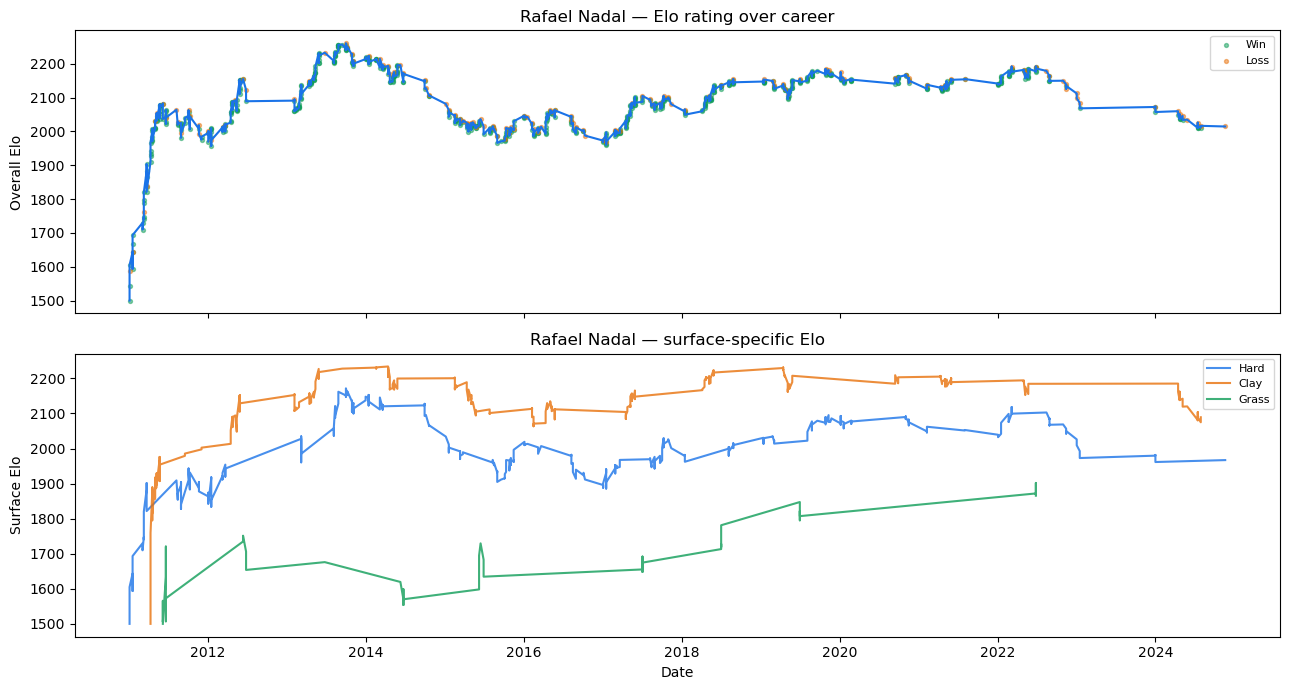

Peak overall Elo : 2261  (2013-09-30)


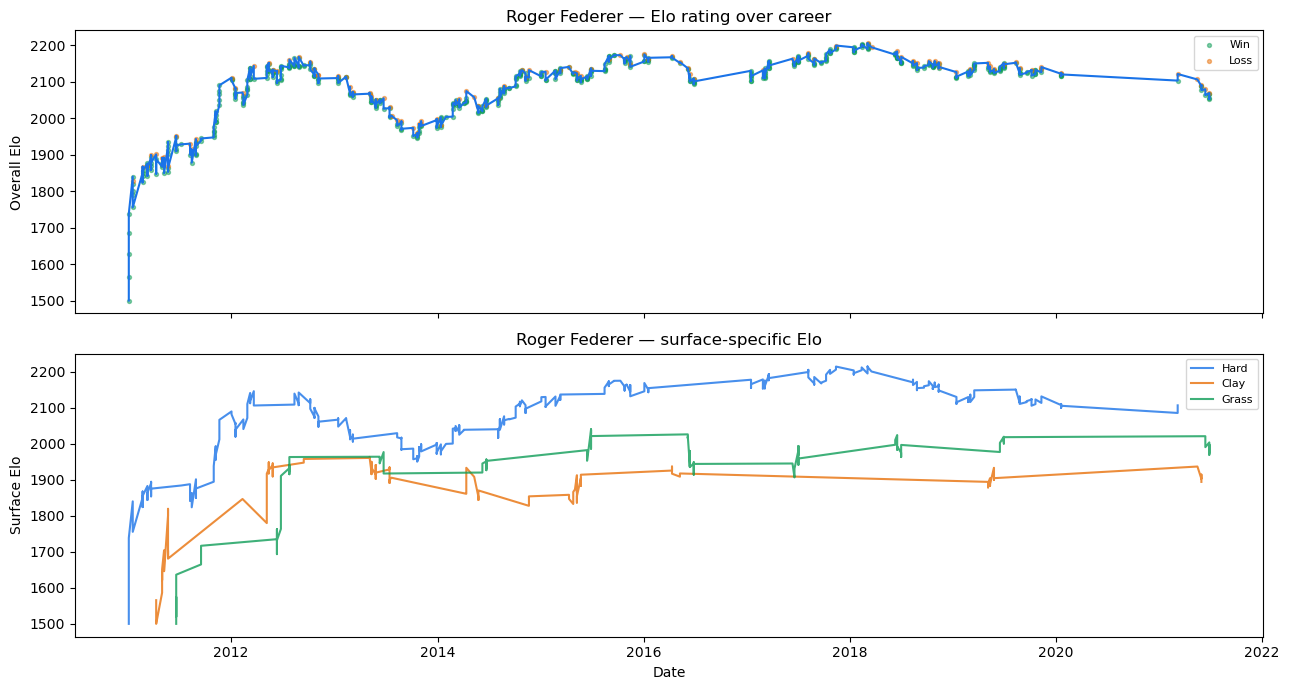

Peak overall Elo : 2206  (2018-03-05)


In [13]:
def plot_player_elo(player_name, raw, elo_df):
    name_lower = player_name.lower()
    mask_w = raw["winner_name"].str.lower().str.contains(name_lower, na=False)
    mask_l = raw["loser_name"].str.lower().str.contains(name_lower, na=False)

    candidates = pd.concat([
        raw[mask_w][["winner_id","winner_name"]].rename(
            columns={"winner_id":"id","winner_name":"name"}),
        raw[mask_l][["loser_id","loser_name"]].rename(
            columns={"loser_id":"id","loser_name":"name"}),
    ]).drop_duplicates()

    if candidates.empty:
        print(f"Player '{player_name}' not found")
        return
    if len(candidates) > 1:
        print(f"Multiple matches: {candidates['name'].tolist()}")
        return

    pid  = candidates.iloc[0]["id"]
    name = candidates.iloc[0]["name"]

    player_matches = raw[
        (raw["winner_id"]==pid) | (raw["loser_id"]==pid)
    ].copy()
    player_matches["mid"] = (player_matches["tourney_id"].astype(str)
                              + "_" + player_matches["match_num"].astype(str))

    elo_history = []
    for _, r in player_matches.iterrows():
        mid = r["mid"]
        if mid not in elo_df.index:
            continue
        role = "winner" if r["winner_id"] == pid else "loser"
        elo_history.append({
            "date":        r["tourney_date"],
            "tournament":  r.get("tourney_name",""),
            "surface":     r.get("surface",""),
            "elo":         float(elo_df.loc[mid, f"{role}_elo"]),
            "elo_surface": float(elo_df.loc[mid, f"{role}_elo_surf"]),
            "won":         1 if role=="winner" else 0,
        })

    df_elo = pd.DataFrame(elo_history).sort_values("date")

    fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

    # Overall Elo
    ax = axes[0]
    ax.plot(df_elo["date"], df_elo["elo"], color="#1a73e8", lw=1.5)
    wins = df_elo[df_elo["won"]==1]
    loss = df_elo[df_elo["won"]==0]
    ax.scatter(wins["date"], wins["elo"], color="#0f9d58", s=8, alpha=0.5, label="Win")
    ax.scatter(loss["date"], loss["elo"], color="#e8710a", s=8, alpha=0.5, label="Loss")
    ax.set_ylabel("Overall Elo")
    ax.set_title(f"{name} — Elo rating over career")
    ax.legend(fontsize=8)

    # Surface Elo by surface
    ax2 = axes[1]
    surface_colors = {"Hard":"#1a73e8","Clay":"#e8710a","Grass":"#0f9d58"}
    for surf, color in surface_colors.items():
        s_df = df_elo[df_elo["surface"]==surf]
        if not s_df.empty:
            ax2.plot(s_df["date"], s_df["elo_surface"],
                     color=color, lw=1.5, label=surf, alpha=0.8)
    ax2.set_ylabel("Surface Elo")
    ax2.set_xlabel("Date")
    ax2.set_title(f"{name} — surface-specific Elo")
    ax2.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig(f"elo_{player_name.replace(' ','_')}.png", dpi=150)
    plt.show()
    print(f"Peak overall Elo : {df_elo['elo'].max():.0f}  "
          f"({df_elo.loc[df_elo['elo'].idxmax(),'date'].date()})")

# Exemples
plot_player_elo("Djokovic", raw, elo_df)
plot_player_elo("Nadal",    raw, elo_df)
plot_player_elo("Federer",  raw, elo_df)

In [14]:
# Let's rank players by absolute surface_elo
def surface_ranking(raw, elo_df, surface="Clay", top_n=15,
                     min_overall_elo=1700, min_surface_matches=20):
    """
    Ranks players by their peak surface-specific Elo — absolute dominance,
    not relative improvement. This correctly puts Nadal at the top of clay.
    """
    surface_match_count = {}
    for _, r in raw.iterrows():
        surf = r.get("surface","")
        if surf != surface: continue
        for role in ["winner","loser"]:
            pid = r.get(f"{role}_id")
            if pd.notna(pid):
                key = (pid, surface)
                surface_match_count[key] = surface_match_count.get(key, 0) + 1

    latest = {}
    for _, r in raw.sort_values("tourney_date").iterrows():
        mid  = f"{r['tourney_id']}_{r['match_num']}"
        surf = r.get("surface","")
        if mid not in elo_df.index or surf != surface: continue
        for role in ["winner","loser"]:
            pid  = r.get(f"{role}_id")
            name = r.get(f"{role}_name")
            if pd.isna(pid): continue
            latest[pid] = {
                "name":             name,
                "overall_elo":      float(elo_df.loc[mid, f"{role}_elo"]),
                "surface_elo":      float(elo_df.loc[mid, f"{role}_elo_surf"]),
                "n_surface_matches":surface_match_count.get((pid, surface), 0),
            }

    df = pd.DataFrame(list(latest.values()))
    df["gap"] = df["surface_elo"] - df["overall_elo"]

    df_f = df[
        (df["overall_elo"] >= min_overall_elo) &
        (df["n_surface_matches"] >= min_surface_matches)
    ].copy()

    print(f"\n{'='*55}")
    print(f"  TOP {top_n} on {surface.upper()} — by absolute surface Elo")
    print(f"{'='*55}")
    top = df_f.nlargest(top_n, "surface_elo")[
        ["name","overall_elo","surface_elo","gap","n_surface_matches"]
    ]
    print(top.to_string(index=False))

    print(f"\n  TOP {top_n} SPECIALISTS — most improved vs their own baseline")
    print(f"  (gap = surface_elo − overall_elo)")
    spec = df_f.nlargest(top_n, "gap")[
        ["name","overall_elo","surface_elo","gap","n_surface_matches"]
    ]
    print(spec.to_string(index=False))

    return df_f

# Run for each surface
clay  = surface_ranking(raw, elo_df, surface="Clay")
grass = surface_ranking(raw, elo_df, surface="Grass")
hard  = surface_ranking(raw, elo_df, surface="Hard")


  TOP 15 on CLAY — by absolute surface Elo
              name  overall_elo  surface_elo         gap  n_surface_matches
      Rafael Nadal  2016.553228  2089.255466   72.702238                319
    Carlos Alcaraz  2159.991546  2076.142792  -83.848753                 99
    Novak Djokovic  2163.825740  2036.515973 -127.309767                248
Stefanos Tsitsipas  1933.760985  2004.514532   70.753547                153
  Alexander Zverev  2019.517842  2001.304215  -18.213627                206
       Casper Ruud  1963.288010  1972.793154    9.505144                199
 Matteo Berrettini  1911.264435  1954.402055   43.137620                 85
     Roger Federer  2088.127328  1902.615778 -185.511550                102
     Jannik Sinner  2161.487483  1894.696593 -266.790890                 78
   Karen Khachanov  1914.028581  1863.858532  -50.170049                118
       Holger Rune  1881.641733  1862.907477  -18.734256                 75
       Andy Murray  1732.038472  1856.952502